### Выгружаем данные и приводим к бинарной классификации

In [ ]:
import pandas as pd
import numpy as np

#### google colab или kaggle |

In [ ]:
!gdown 1jxmlIYFahzo2qk8CbjGj1YpEz4YwqYQx

In [ ]:
import zipfile

zip_path = 'memedataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("📁 Архив распакован.")


📁 Архив распакован.


In [ ]:
images_folder = '/content/dataset/train/'
test_folder = '/content/dataset/test/'

df = pd.read_csv('/content/dataset/train.csv')
test = pd.read_csv('/content/dataset/test.csv')

df['label'] = (df['label'] == 0).astype(int)
test['label'] = (test['label'] == 0).astype(int)

df.head()

,filename,url,label
0,dd04baf8a1ec4e99b661fc50ce11f3fb.jpg,https://sun1-29.userapi.com/s/v1/ig2/RCHXNPoCm...,0
1,85a5f9b8af0a145df51d2a9ba6722ff9.jpg,https://sun1-19.userapi.com/s/v1/ig2/lMzHt5ja6...,0
2,ba334090dd827a881f02581c09b7980d.jpg,https://sun9-73.userapi.com/s/v1/ig2/nTnnvHD_7...,0
3,bbbc5f3698c7f426b8886a110175a273.jpg,https://sun1-87.userapi.com/s/v1/ig2/WnAX9NlUv...,0
4,ceb955741afa84345f646814b86a5425.jpg,https://sun1-21.userapi.com/s/v1/ig2/tGsdVQTGP...,0


#### локальный запуск |

In [ ]:
# для локального запуска
import os

if os.getcwd().split('/')[-1] != 'memobot':
    os.chdir('..')
os.getcwd()


'/'

In [ ]:
# images_folder = 'data/train/'
# test_folder = 'data/test/'

# df = pd.read_csv('data/train.csv')
# test = pd.read_csv('data/test.csv')
# df['label'] = (df['label'] == 0).astype(int)
# test['label'] = (test['label'] == 0).astype(int)
# df.head()

## Делаем датасет

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os


class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data = VkDataset(df, images_folder, transform=transform)
test_data = VkDataset(test, test_folder, transform=transform)

groups = ['not cu', 'central_university']

🖼️ Batch size: torch.Size([32, 3, 224, 224]), Labels: tensor([0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0])


In [7]:
len(data), len(test_data)

(2670, 680)

### проверяем что все верно

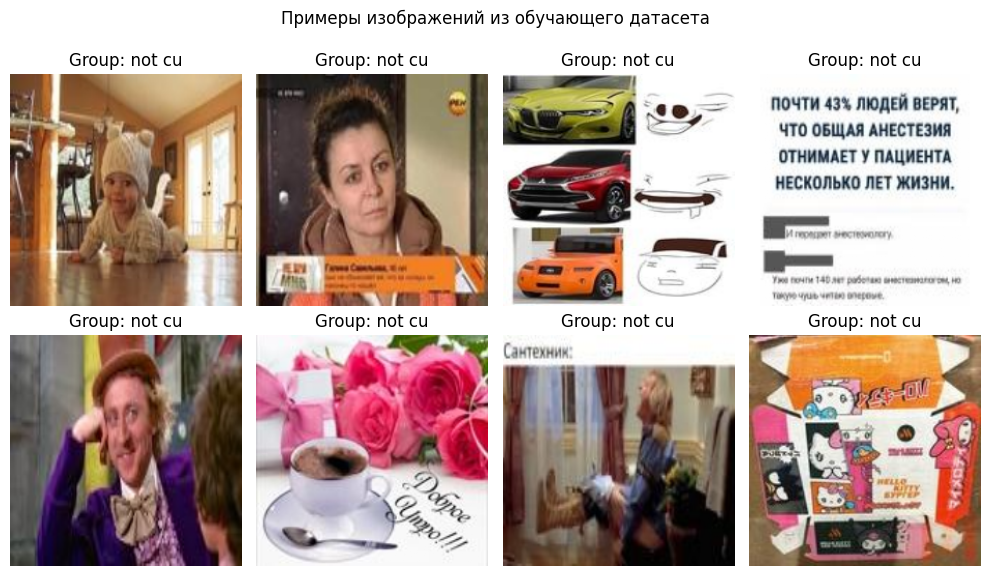

In [16]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 0
for i in np.random.randint(0, len(data), 8):
    plt.subplot(2, 4, j + 1)
    j += 1
    img = data[i][0]
    label = data[i][1]
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Делим на train val test, и подаем в DataLoader

In [1]:
from torch.utils.data import random_split
import torch

torch.manual_seed(42)

train_ds, val_ds = random_split(data, [0.8, 0.2])

NameError: name 'data' is not defined

### Функции для обучения и теста моделей

In [ ]:
from sklearn.metrics import f1_score
import torch.nn as nn
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def train_model(model, file_path, n_epochs=5, batch_size=32, optimizer=None, criterion=None):
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    
    if not optimizer:
        optimizer = torch.optim.Adam(model.parameters())
    if not criterion:
        criterion = nn.CrossEntropyLoss()

    best_score = 0

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        train_iterator = tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]", leave=False)
        for image, label in train_iterator:
            image, label = image.to(device), label.to(device)
            logits = model(image)
            loss = criterion(logits, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        model.eval()
        val_loss = 0
        total_f1 = 0
        val_iterator = tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]", leave=False)

        with torch.no_grad():
            for image, label in val_iterator:
                image, label = image.to(device), label.to(device)
                logits = model(image)

                loss = criterion(logits, label)
                preds = logits.softmax(dim=1).argmax(dim=1)
                all_labels.extend(label.cpu())
                all_preds.extend(preds.cpu())
                val_loss += loss.item()

        total_f1 = f1_score(all_preds, all_labels)
        val_loss /= len(val_dl)
        total_loss /= len(train_dl)

        if total_f1 > best_score:
            best_score = total_f1
            os.makedirs(os.path.dirname(file_path), exist_ok=True)
            torch.save(model.state_dict(), file_path)

        print(f'Epoch {epoch+1}: Train Loss = {total_loss:.3f}, Val Loss = {val_loss:.3f}, F1 = {total_f1:.3f}')



def test_model(model, criterion, batch_size=32):
    if not criterion:
        criterion = nn.CrossEntropyLoss()
    
    test_dl = DataLoader(test_data, batch_size=batch_size, shuffle=True)
    model.eval()
    
    test_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(test_dl, desc='[Test]'):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            preds = model(images)
            loss = criterion(preds, labels)
        test_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    test_loss /= len(test_dl)
    f1 = f1_score(all_labels, all_preds)
    print(f'Test Loss = {test_loss:.3f}, f1_score = {f1:.3f}')


def check_quality(model):
    plt.subplots(2, 4, figsize=(10, 6))
    plt.suptitle("Примеры изображений из обучающего датасета")
    j = 1
    for i in np.random.randint(0, len(test_data), 8):
        plt.subplot(2, 4, j)
        j += 1

        img = test_data[i][0].to(device).unsqueeze(0)
        
        with torch.no_grad():
            logit = model(img)
            label = logit.softmax(dim=1).argmax(dim=1).item()
        plt.imshow(test_data[i][0].permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
        plt.title(f"Group: {groups[label]}")
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


### ResNet

In [3]:
import torchvision.models as models

model = models.resnet50()
model.fc = nn.Linear(2048, 2)
model = model.to(device)

In [ ]:
train_model(model, 'data/resnet50.pth')

In [14]:
# model = torch.load('best_model.pth', weights_only=False)

In [5]:
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(2048, 2)
model = model.to(device)
state_dict = torch.load('data/resnet50.pth')
model.load_state_dict(state_dict)

/Users/mhlgvr/miniforge3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mhlgvr/miniforge3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'data/resnet50.pth'

### допом проверим глазками

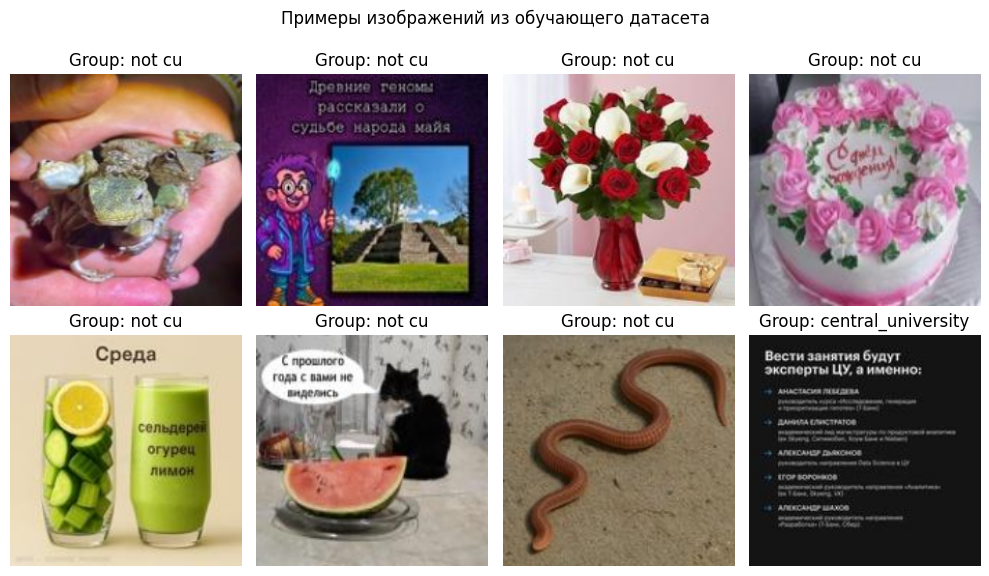

In [ ]:
check_quality(model)

## EfficientNet

In [ ]:
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(1280, 2)
model.to(device)

In [ ]:
train_model(model, 'data/efficientnet.pth')

In [ ]:
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(1280, 2)
model = model.to(device)
state_dict = torch.load('data/efficientnet.pth')
model.load_state_dict(state_dict)

In [ ]:
test_model(model)

In [ ]:
check_quality(model)

## ViT